# data cleaning

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn

In [3]:
train = pd.read_csv('train_(2)_(1)_(1)_(1).csv')
test = pd.read_csv('test_(2)_(1)_(1)_(1).csv')
avgRent = pd.read_csv('avg_rent_(1)_(1)_(1)_(1).csv')
disCityCenter = pd.read_csv('dist_from_city_centre_(1)_(1)_(1)_(1).csv')
sampleSubmission = pd.read_csv('sample_submission_(3)_(1)_(1)_(1).csv')

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10656 entries, 0 to 10655
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            10656 non-null  int64  
 1   area_type     10656 non-null  object 
 2   availability  10656 non-null  object 
 3   location      10655 non-null  object 
 4   size          10642 non-null  object 
 5   society       6228 non-null   object 
 6   total_sqft    10656 non-null  object 
 7   bath          10591 non-null  float64
 8   balcony       10152 non-null  float64
 9   price         10656 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 832.6+ KB


In [5]:
train.dropna(subset=['size', 'location', 'bath', 'balcony'], inplace=True)


In [6]:
avgRent.head()


,location,avg_2bhk_rent
0,Krishnarajapura,11954
1,Sarjapur,45000
2,Whitefield Hope Farm Junction,26370
3,Devanahalli,17302
4,Whitefield,14981


In [7]:
# avgRent.loc[]

avgRent[avgRent.location.str.contains("Electronic")]

,location,avg_2bhk_rent
7,Electronic City Phase 1,18891
15,Electronics City,10650
27,Electronic City Phase 2,14000
123,Electronic City Phase II,11500


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10151 entries, 0 to 10654
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            10151 non-null  int64  
 1   area_type     10151 non-null  object 
 2   availability  10151 non-null  object 
 3   location      10151 non-null  object 
 4   size          10151 non-null  object 
 5   society       5959 non-null   object 
 6   total_sqft    10151 non-null  object 
 7   bath          10151 non-null  float64
 8   balcony       10151 non-null  float64
 9   price         10151 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 872.4+ KB


### cleaning total_sqft and making it numeric 
as it is expected to be in sq feet

then scaling it

In [10]:
def is_number(x):
    try:
        float(x)
        return True
    except ValueError:
        return False

In [11]:
# train[train.total_sqft.apply(lambda x: is_number(x) == False)]

In [12]:
def return_sqft(x):
    if is_number(x):
        return float(x)
    
    tokens = x.split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    if x.endswith('Sq. Meter') or x.endswith('Sq. Meter'):
        x = float(x.split('Sq')[0])
        return x*10.7639
    if x.endswith('Acres'):
        x = float(x.split('Acr')[0])
        return x*43560
    if x.endswith('Sq. Yards'):
        x = float(x.split('Sq')[0])
        return x*10.7639
    if x.endswith('Grounds'):
        x = float(x.split('Gro')[0])
        return x*2400
    if x.endswith('Cents'):
        x = float(x.split('Cen')[0])
        return x*435.6
    if x.endswith('Perch'):
        x = float(x.split('Per')[0])
        return x*272.25
    if x.endswith('Guntha'):
        x = float(x.split('Gun')[0])
        return x*1089
    
    print("Couldn't parse the value: ", x)
    return x

In [13]:
train['total_sqft'] = train.total_sqft.apply(lambda x: return_sqft(x))

In [14]:
train[train.total_sqft.apply(lambda x: is_number(x) == False)]


,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,price


In [46]:
train.total_sqft.describe()

count   10143.000000
mean        0.001368
std         0.012356
min         0.000000
25%         0.000804
50%         0.000929
75%         0.001220
max         1.000000
Name: total_sqft, dtype: float64

outlier treatment for total_sqft based on area_type

In [17]:
train.area_type.value_counts()

area_type
Super built-up  Area    6745
Built-up  Area          1845
Plot  Area              1496
Carpet  Area              65
Name: count, dtype: int64

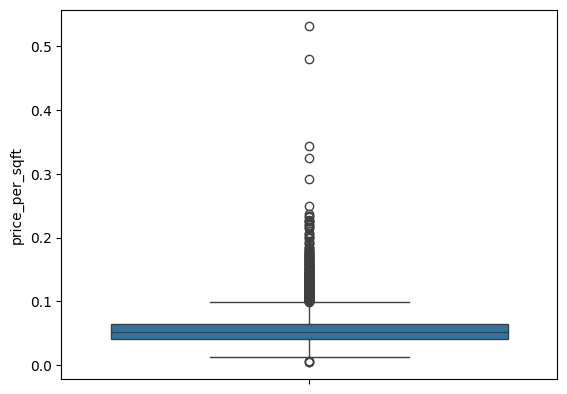

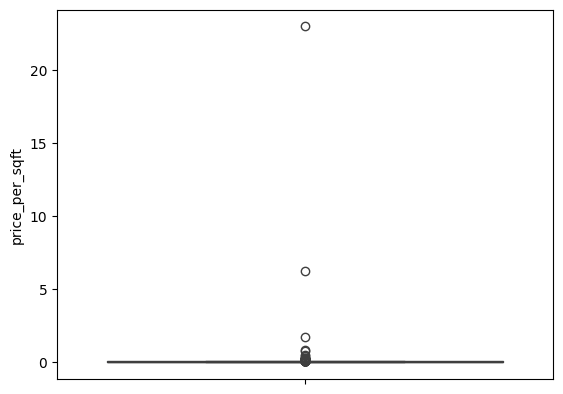

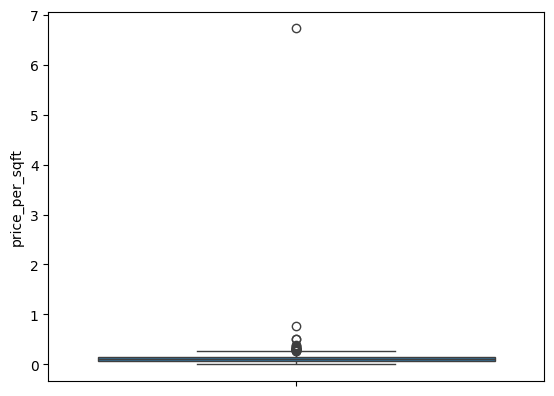

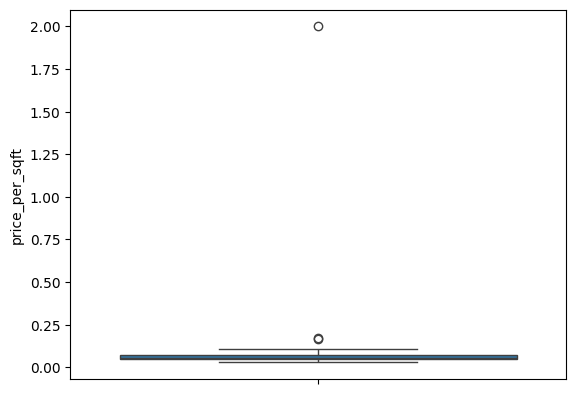

In [18]:
# TODO: outlier analysis to be done wrt area type 

train['price_per_sqft'] = train.price / train.total_sqft

sns.boxplot(train[train.area_type == 'Super built-up  Area'].price_per_sqft)
plt.show()

# train = train[~(train.price_per_sqft < 10)]

sns.boxplot(train[train.area_type == 'Built-up  Area'].price_per_sqft)
plt.show()

sns.boxplot(train[train.area_type == 'Plot  Area'].price_per_sqft)
plt.show()

sns.boxplot(train[train.area_type == 'Carpet  Area'].price_per_sqft)
plt.show()

In [19]:
train.price_per_sqft.describe()

count    10151.000000
mean         0.069261
std          0.249677
min          0.000023
25%          0.042426
50%          0.053968
75%          0.071713
max         23.000000
Name: price_per_sqft, dtype: float64

In [20]:
train[train.price_per_sqft > .6]

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,price,price_per_sqft
1887,6421,Plot Area,18-Sep,Bommenahalli,4 Bedroom,Prood G,2940.0000,3.0,2.0,2250.0,0.765306
3391,1122,Built-up Area,Ready To Move,Grihalakshmi Layout,5 Bedroom,NaN,24.0000,2.0,2.0,150.0,6.250000
4945,5668,Built-up Area,Ready To Move,Judicial Layout,5 Bedroom,NaN,484.3755,6.0,3.0,400.0,0.825806
7600,7657,Built-up Area,Ready To Move,Raghuvanahalli,1 BHK,NaN,425.0000,1.0,1.0,750.0,1.764706
8833,4972,Built-up Area,Ready To Move,Srirampuram,7 BHK,NaN,5.0000,7.0,3.0,115.0,23.000000
8835,7088,Built-up Area,Ready To Move,Srirampuram,1 BHK,NaN,650.0000,1.0,3.0,500.0,0.769231
8913,349,Plot Area,18-Dec,Suragajakkanahalli,3 Bedroom,PrhyaK,11.0000,3.0,2.0,74.0,6.727273
9898,1020,Carpet Area,Ready To Move,Weavers Colony,1 BHK,NaN,15.0000,1.0,0.0,30.0,2.000000


In [21]:
train.drop(train[train.price_per_sqft > 0.6].index, inplace=True, axis=0)

In [22]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10143 entries, 0 to 10654
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              10143 non-null  int64  
 1   area_type       10143 non-null  object 
 2   availability    10143 non-null  object 
 3   location        10143 non-null  object 
 4   size            10143 non-null  object 
 5   society         5957 non-null   object 
 6   total_sqft      10143 non-null  float64
 7   bath            10143 non-null  float64
 8   balcony         10143 non-null  float64
 9   price           10143 non-null  float64
 10  price_per_sqft  10143 non-null  float64
dtypes: float64(5), int64(1), object(5)
memory usage: 950.9+ KB


In [ ]:
# note that we must do outlier treatment before scaling
# min max scaling for total_sqft

train.total_sqft = train.total_sqft.apply(lambda x: (x - train.total_sqft.min())/(train.total_sqft.max() - train.total_sqft.min()))

successfully cleaned all non numeric data from total_sqft col

## handling size
- currently 1rk = 0
- 1bhk/1bedroom = 1
- 2bhk/2bedroom = 2 
and soo on

In [23]:
train['size'].value_counts(dropna=False)

size
2 BHK         4108
3 BHK         3270
4 Bedroom      596
3 Bedroom      427
1 BHK          426
4 BHK          390
2 Bedroom      280
5 Bedroom      204
6 Bedroom      137
1 Bedroom       88
7 Bedroom       54
8 Bedroom       51
5 BHK           31
9 Bedroom       26
6 BHK           16
1 RK            13
7 BHK           10
9 BHK            5
11 Bedroom       2
8 BHK            2
11 BHK           1
14 BHK           1
13 BHK           1
27 BHK           1
43 Bedroom       1
10 Bedroom       1
12 Bedroom       1
Name: count, dtype: int64

In [24]:
train[train['size'].apply(lambda x: is_number(x) == False)]


,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,price,price_per_sqft
0,2557,Built-up Area,Ready To Move,Anekal,1 RK,NaN,351.0,1.0,1.0,16.00,0.045584
1,8385,Super built-up Area,Ready To Move,Banaswadi,1 RK,Krntsee,527.0,1.0,0.0,35.00,0.066414
2,7638,Super built-up Area,Ready To Move,Basavangudi,1 RK,NaN,670.0,1.0,1.0,50.00,0.074627
3,2486,Super built-up Area,19-Dec,Bhoganhalli,1 RK,Rosha I,296.0,1.0,0.0,22.89,0.077331
4,2764,Super built-up Area,Ready To Move,Devarabeesana Halli,2 BHK,NaN,1100.0,2.0,1.0,70.00,0.063636
...,...,...,...,...,...,...,...,...,...,...,...
10649,10445,Super built-up Area,Ready To Move,Yeshwanthpur,2 BHK,IBityin,1164.0,2.0,2.0,64.08,0.055052
10650,10460,Super built-up Area,Ready To Move,Yeshwanthpur,3 BHK,IBityin,1520.0,3.0,3.0,85.00,0.055921
10652,10608,Super built-up Area,Ready To Move,Yeshwanthpur,1 BHK,IBityin,674.0,1.0,1.0,36.85,0.054674
10653,4835,Super built-up Area,Ready To Move,Yeshwanthpur Industrial Suburb,3 BHK,NaN,2100.0,3.0,2.0,240.00,0.114286


In [25]:
def returnSize(x):
    try:
        if x == '1 RK':
            return 0
        else:
            return int(x.split(' ')[0])
    except:
        print("Couldn't parse size: ", x)

In [26]:
train['size'] = train['size'].apply(lambda x: returnSize(x))

In [27]:
train

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,price,price_per_sqft
0,2557,Built-up Area,Ready To Move,Anekal,0,NaN,351.0,1.0,1.0,16.00,0.045584
1,8385,Super built-up Area,Ready To Move,Banaswadi,0,Krntsee,527.0,1.0,0.0,35.00,0.066414
2,7638,Super built-up Area,Ready To Move,Basavangudi,0,NaN,670.0,1.0,1.0,50.00,0.074627
3,2486,Super built-up Area,19-Dec,Bhoganhalli,0,Rosha I,296.0,1.0,0.0,22.89,0.077331
4,2764,Super built-up Area,Ready To Move,Devarabeesana Halli,2,NaN,1100.0,2.0,1.0,70.00,0.063636
...,...,...,...,...,...,...,...,...,...,...,...
10649,10445,Super built-up Area,Ready To Move,Yeshwanthpur,2,IBityin,1164.0,2.0,2.0,64.08,0.055052
10650,10460,Super built-up Area,Ready To Move,Yeshwanthpur,3,IBityin,1520.0,3.0,3.0,85.00,0.055921
10652,10608,Super built-up Area,Ready To Move,Yeshwanthpur,1,IBityin,674.0,1.0,1.0,36.85,0.054674
10653,4835,Super built-up Area,Ready To Move,Yeshwanthpur Industrial Suburb,3,NaN,2100.0,3.0,2.0,240.00,0.114286


In [28]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10143 entries, 0 to 10654
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              10143 non-null  int64  
 1   area_type       10143 non-null  object 
 2   availability    10143 non-null  object 
 3   location        10143 non-null  object 
 4   size            10143 non-null  int64  
 5   society         5957 non-null   object 
 6   total_sqft      10143 non-null  float64
 7   bath            10143 non-null  float64
 8   balcony         10143 non-null  float64
 9   price           10143 non-null  float64
 10  price_per_sqft  10143 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 950.9+ KB


## avilibility


In [29]:
train.availability.value_counts()

availability
Ready To Move    8050
18-Dec            223
18-May            220
18-Apr            197
18-Aug            162
                 ... 
20-Apr              1
16-Jul              1
20-Feb              1
14-Nov              1
15-Aug              1
Name: count, Length: 75, dtype: int64

In [30]:
from datetime import datetime

def noOfDays(x):
    if x == 'Ready To Move':
        return 0
    tokens = x.split('-')
    if len(tokens) == 2:
        now = datetime.now()

        date = datetime.strptime(f'{x}-{now.year}', '%d-%b-%Y')

        if (date - now).days < 0:
            date = datetime.strptime(f'{x}-{now.year + 1}', '%d-%b-%Y')
            
        return (date - now).days
    else:
        print("Couldn't parse availability: ", x)
        return -1

In [31]:
train.availability = train.availability.apply(lambda x: noOfDays(x))

In [32]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10143 entries, 0 to 10654
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              10143 non-null  int64  
 1   area_type       10143 non-null  object 
 2   availability    10143 non-null  int64  
 3   location        10143 non-null  object 
 4   size            10143 non-null  int64  
 5   society         5957 non-null   object 
 6   total_sqft      10143 non-null  float64
 7   bath            10143 non-null  float64
 8   balcony         10143 non-null  float64
 9   price           10143 non-null  float64
 10  price_per_sqft  10143 non-null  float64
dtypes: float64(5), int64(3), object(3)
memory usage: 950.9+ KB


In [33]:
train.area_type.value_counts()  

area_type
Super built-up  Area    6745
Built-up  Area          1840
Plot  Area              1494
Carpet  Area              64
Name: count, dtype: int64

In [34]:
train

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,price,price_per_sqft
0,2557,Built-up Area,0,Anekal,0,NaN,351.0,1.0,1.0,16.00,0.045584
1,8385,Super built-up Area,0,Banaswadi,0,Krntsee,527.0,1.0,0.0,35.00,0.066414
2,7638,Super built-up Area,0,Basavangudi,0,NaN,670.0,1.0,1.0,50.00,0.074627
3,2486,Super built-up Area,356,Bhoganhalli,0,Rosha I,296.0,1.0,0.0,22.89,0.077331
4,2764,Super built-up Area,0,Devarabeesana Halli,2,NaN,1100.0,2.0,1.0,70.00,0.063636
...,...,...,...,...,...,...,...,...,...,...,...
10649,10445,Super built-up Area,0,Yeshwanthpur,2,IBityin,1164.0,2.0,2.0,64.08,0.055052
10650,10460,Super built-up Area,0,Yeshwanthpur,3,IBityin,1520.0,3.0,3.0,85.00,0.055921
10652,10608,Super built-up Area,0,Yeshwanthpur,1,IBityin,674.0,1.0,1.0,36.85,0.054674
10653,4835,Super built-up Area,0,Yeshwanthpur Industrial Suburb,3,NaN,2100.0,3.0,2.0,240.00,0.114286


## encoding area type

n-1 dummy encoding performed 

with value counts

- area_type
- Super built-up  Area    6745
- Built-up  Area          1845
- Plot  Area              1496
- Carpet  Area              65

model performance to be tested including only Super built-up  Area 

In [35]:
temp = True
for i in train.area_type.unique():
    if temp:
        temp = False
        continue
    train["area_type_" + i.split("  ")[0].replace(" ", "_").replace("-", "_")] = train.area_type.apply(lambda x: 1 if x==i else 0)

train.drop('area_type', axis=1, inplace=True)

In [36]:
train

,ID,availability,location,size,society,total_sqft,bath,balcony,price,price_per_sqft,area_type_Super_built_up,area_type_Plot,area_type_Carpet
0,2557,0,Anekal,0,NaN,351.0,1.0,1.0,16.00,0.045584,0,0,0
1,8385,0,Banaswadi,0,Krntsee,527.0,1.0,0.0,35.00,0.066414,1,0,0
2,7638,0,Basavangudi,0,NaN,670.0,1.0,1.0,50.00,0.074627,1,0,0
3,2486,356,Bhoganhalli,0,Rosha I,296.0,1.0,0.0,22.89,0.077331,1,0,0
4,2764,0,Devarabeesana Halli,2,NaN,1100.0,2.0,1.0,70.00,0.063636,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10649,10445,0,Yeshwanthpur,2,IBityin,1164.0,2.0,2.0,64.08,0.055052,1,0,0
10650,10460,0,Yeshwanthpur,3,IBityin,1520.0,3.0,3.0,85.00,0.055921,1,0,0
10652,10608,0,Yeshwanthpur,1,IBityin,674.0,1.0,1.0,36.85,0.054674,1,0,0
10653,4835,0,Yeshwanthpur Industrial Suburb,3,NaN,2100.0,3.0,2.0,240.00,0.114286,1,0,0


In [37]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10143 entries, 0 to 10654
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        10143 non-null  int64  
 1   availability              10143 non-null  int64  
 2   location                  10143 non-null  object 
 3   size                      10143 non-null  int64  
 4   society                   5957 non-null   object 
 5   total_sqft                10143 non-null  float64
 6   bath                      10143 non-null  float64
 7   balcony                   10143 non-null  float64
 8   price                     10143 non-null  float64
 9   price_per_sqft            10143 non-null  float64
 10  area_type_Super_built_up  10143 non-null  int64  
 11  area_type_Plot            10143 non-null  int64  
 12  area_type_Carpet          10143 non-null  int64  
dtypes: float64(5), int64(6), object(2)
memory usage: 1.1+ MB


In [38]:
# import 'Pandas' 
import pandas as pd 

# import 'Numpy' 
import numpy as np

# import subpackage of Matplotlib
import matplotlib.pyplot as plt

# import 'Seaborn' 
import seaborn as sns

# to suppress warnings 
from warnings import filterwarnings
filterwarnings('ignore')

# display all columns of the dataframe
pd.options.display.max_columns = None

# display all rows of the dataframe
pd.options.display.max_rows = None
 
# to display the float values upto 6 decimal places     
pd.options.display.float_format = '{:.6f}'.format

# import train-test split 
from sklearn.model_selection import train_test_split

# # import various functions from statsmodels
# import statsmodels
# import statsmodels.api as sm
# import statsmodels.stats.api as sms
# from statsmodels.graphics.gofplots import qqplot

# # import 'stats'
# from scipy import stats

# # 'metrics' from sklearn is used for evaluating the model performance
# from sklearn.metrics import mean_squared_error

# # import functions to perform feature selection
# from mlxtend.feature_selection import SequentialFeatureSelector as sfs
# #from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import RFE

# import function to perform linear regression
from sklearn.linear_model import LinearRegression

# import functions to perform cross validation
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

In [39]:
# initiate linear regression model to use in feature selection
linreg = LinearRegression()

# build forward feature selection
# pass the regression model to 'estimator'
# pass number of required feartures to 'k_features'. Here '12' is the stopping rule
# 'forward=True' performs forward selection method
# 'verbose=1' returns the number of features at the corresponding step
# 'verbose=2' returns the R-squared scores and the number of features at the corresponding step
# 'scoring=r2' considers R-squared score to select the feature
# linreg_forward = sfs(estimator=linreg, k_features = 12, forward=True,
#                      verbose=2, scoring='r2')

# fit the forward selection on training data using fit()
# sfs_forward = linreg_forward.fit(X_train, y_train)


linreg.fit(X_train, y_train)

print(f"Model Score: {model.score(X_test, y_test)}")

NameError: name 'X_train' is not defined